In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

In [2]:
BASE_DIR=Path(os.getcwd())
FILTERED_DIR=BASE_DIR/"brd4_pipeline"/"data"/"filtered"
PROCESSED_DIR=BASE_DIR/"brd4_pipeline"/"data"/"processed"

df=pd.read_csv(FILTERED_DIR/"brd4_final_clean.csv")

print(f"[INFO] Loaded {len(df):,} molecules from module 1")
print(f"Columns available : {df.columns.tolist()}")
print(df[['molecule_chembl_id','smiles_clean','pIC50']].head(3))

[INFO] Loaded 2,909 molecules from module 1
Columns available : ['assay_type', 'canonical_smiles', 'data_validity_comment', 'molecule_chembl_id', 'pchembl_value', 'standard_type', 'standard_units', 'standard_value', 'type', 'units', 'value', 'standard_value_nM', 'pIC50', 'smiles_clean', 'is_pains']
  molecule_chembl_id                                       smiles_clean  \
0      CHEMBL3902148  C[C@H]1NC(=O)c2cc(-c3c(F)ccc4c(=O)n(C)c(NC(C)(...   
1      CHEMBL3940091  CC(C)n1c(NC(C)(C)C)nc2c(-c3cc4c([nH]3)[C@@H](C...   
2      CHEMBL4741714  C[C@@H]1C[C@H](N)C[C@H](c2ccccc2NC(=O)c2ccc(F)...   

       pIC50  
0  10.920819  
1  10.920819  
2  10.744727  


In [3]:
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, rdMolDescriptors

In [4]:
def calculate_properties(smiles):
    mol=Chem.MolFromSmiles(smiles)
    if mol is None:
        return {
            'MW':np.nan,
            'LogP':np.nan,
            'HBD':np.nan,
            'HBA':np.nan,
            'TPSA':np.nan,
            'RotB':np.nan}
    return {
        'MW':Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'HBD':rdMolDescriptors.CalcNumHBD(mol),
        'HBA':rdMolDescriptors.CalcNumHBA(mol),
        'TPSA':Descriptors.TPSA(mol),
        'RotB':rdMolDescriptors.CalcNumRotatableBonds(mol)}

print(f"[INFO] Calculating physicochemical properties...")
print("[INFO] This will take 1-2 minute for 2909 molecules.")

props=df['smiles_clean'].apply(calculate_properties)

props_df=pd.DataFrame(props.tolist())

df=pd.concat([df.reset_index(drop=True), props_df], axis=1)

print(f"[DONE] Properties calculated for {len(df):,} molecules.")
print(f"\nProperty statistics:")
print(df[['MW','LogP','HBD','HBA','TPSA','RotB']].describe().round(2))

[INFO] Calculating physicochemical properties...
[INFO] This will take 1-2 minute for 2909 molecules.
[DONE] Properties calculated for 2,909 molecules.

Property statistics:
            MW     LogP      HBD      HBA     TPSA     RotB
count  2909.00  2909.00  2909.00  2909.00  2909.00  2909.00
mean    424.97     3.75     2.37     5.96    93.89     4.24
std      70.00     0.98     0.85     1.62    22.50     1.55
min     205.24     0.26     0.00     1.00    26.93     0.00
25%     373.44     3.06     2.00     5.00    79.38     3.00
50%     418.52     3.73     2.00     6.00    91.93     4.00
75%     472.56     4.44     3.00     7.00   108.64     5.00
max     676.74     7.08     6.00    12.00   179.39    13.00


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

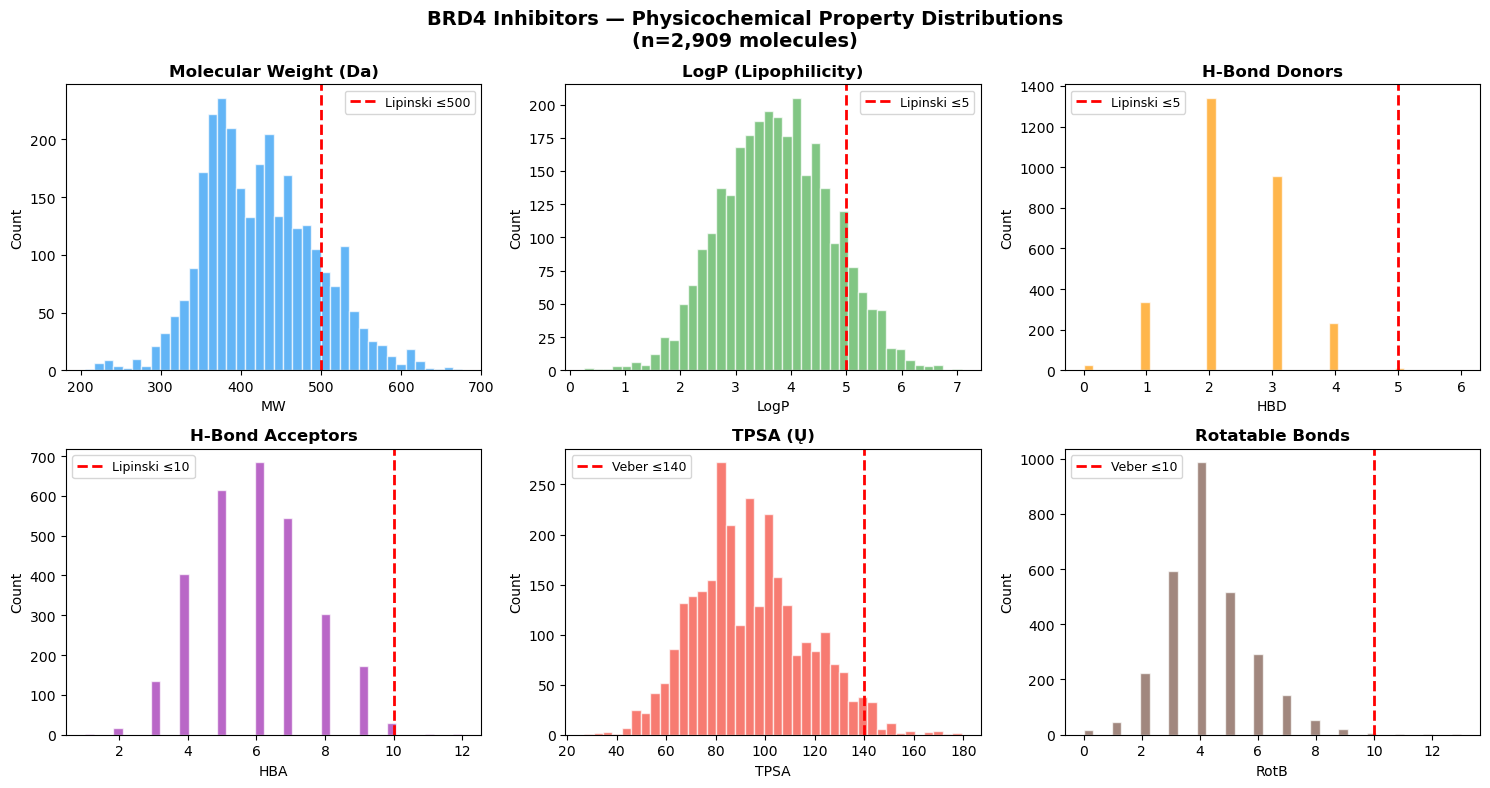

[SAVED] Property distribution plot saved.


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('BRD4 Inhibitors — Physicochemical Property Distributions\n(n=2,909 molecules)', 
             fontsize=14, fontweight='bold')

properties = [
    ('MW',   'Molecular Weight (Da)',    500,  'Lipinski ≤500',  '#2196F3'),
    ('LogP', 'LogP (Lipophilicity)',     5,    'Lipinski ≤5',    '#4CAF50'),
    ('HBD',  'H-Bond Donors',           5,    'Lipinski ≤5',    '#FF9800'),
    ('HBA',  'H-Bond Acceptors',        10,   'Lipinski ≤10',   '#9C27B0'),
    ('TPSA', 'TPSA (Ų)',               140,  'Veber ≤140',     '#F44336'),
    ('RotB', 'Rotatable Bonds',         10,   'Veber ≤10',      '#795548'),
]

for ax, (col, title, limit, limit_label, color) in zip(axes.flat, properties):

    ax.hist(df[col].dropna(), bins=40, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(x=limit, color='red', linestyle='--', linewidth=2, label=limit_label)
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(BASE_DIR / "brd4_pipeline" / "outputs" / "module02_property_distributions.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] Property distribution plot saved.")

In [10]:
print("="*55)
print(" APPLYING DRUG LIKENESS FILTERS")
print("="*55)

before=len(df)
df=df.dropna(subset=['MW','LogP','HBD','HBA','TPSA','RotB'])
after=len(df)
print(f"Dropped {before - after} molecules with failed property calculated")
print(f"Working with : {after:,} molecules\n")

lipinski_pass=(
    (df['MW']<=500) &
    (df['LogP']<=5) &
    (df['HBD']<=5) &
    (df['HBA']<=10))

veber_pass=(
    (df['TPSA']<=140) &
    (df['RotB']<=10))

druglike_pass=lipinski_pass & veber_pass

df['lipinski_pass']=lipinski_pass
df['veber_pass']=veber_pass
df['druglike']=druglike_pass

n_lipinski=lipinski_pass.sum()
n_veber=veber_pass.sum()
n_druglike=druglike_pass.sum()
n_total=len(df)

print(f"Lipinski pass : {n_lipinski:,}/{n_total:,} ({n_lipinski/n_total*100:.1f}%)")
print(f"Veber pass : {n_veber:,}/{n_total:,} ({n_veber/n_total*100:.1f}%)")
print(f"Both Pass : {n_druglike:,}/{n_total:,} ({n_druglike/n_total*100:.1f}%)")
print(f"Removed : {n_total - n_druglike:,} molecules")

df_druglike=df[df['druglike']].copy()
df_nondrug=df[~df['druglike']].copy()

print(f"\nFinal drug - like dataset : {len(df_druglike):,} molecules")

 APPLYING DRUG LIKENESS FILTERS
Dropped 0 molecules with failed property calculated
Working with : 2,909 molecules

Lipinski pass : 2,246/2,909 (77.2%)
Veber pass : 2,825/2,909 (97.1%)
Both Pass : 2,210/2,909 (76.0%)
Removed : 699 molecules

Final drug - like dataset : 2,210 molecules


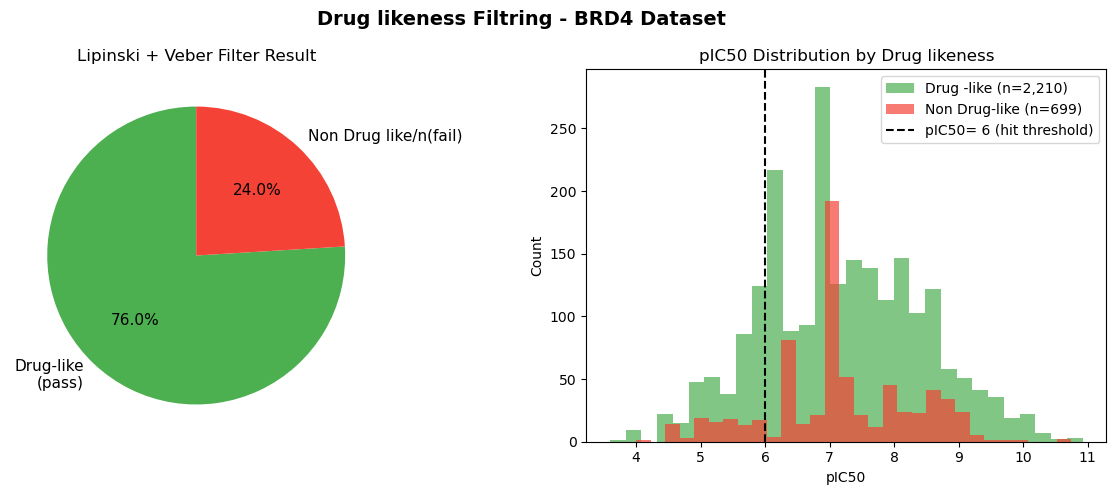

[SAVED] Drug-likeness filter plot saved.


In [15]:
fig, axes=  plt.subplots(1,2 , figsize=(12, 5))
fig.suptitle('Drug likeness Filtring - BRD4 Dataset', fontsize=14, fontweight='bold')

labels=['Drug-like\n(pass)','Non Drug like/n(fail)']
sizes=[len(df_druglike), len(df_nondrug)]
colors=['#4CAF50','#F44336']

axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',startangle=90, textprops={'fontsize':11})
axes[0].set_title('Lipinski + Veber Filter Result')

axes[1].hist(df_druglike['pIC50'], bins=30, alpha=0.7,
             color='#4CAF50', label=f'Drug -like (n={len(df_druglike):,})')
axes[1].hist(df_nondrug['pIC50'], bins=30, alpha=0.7,color='#F44336', label=f'Non Drug-like (n={len(df_nondrug):,})')
axes[1].axvline(x=6.0, color='black',linestyle='--',label='pIC50= 6 (hit threshold)')
axes[1].set_xlabel('pIC50')
axes[1].set_ylabel('Count')
axes[1].set_title('pIC50 Distribution by Drug likeness')
axes[1].legend()
plt.tight_layout()
plt.savefig(BASE_DIR/"brd4_pipeline"/"outputs"/"module02_druglike_filter.png", dpi=150, bbox_inches='tight')
plt.show()
print("[SAVED] Drug-likeness filter plot saved.")

In [14]:
outputs_dir = BASE_DIR / "brd4_pipeline" / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

druglike_file = FILTERED_DIR / "brd4_druglike.csv"
df_druglike.to_csv(druglike_file, index=False)

nondrug_file = FILTERED_DIR / "brd4_nondrug_flagged.csv"
df_nondrug.to_csv(nondrug_file, index=False)

print("=" * 55)
print("  MODULE 2 — PIPELINE AUDIT REPORT")
print("  Target: BRD4 (CHEMBL4523)")
print("=" * 55)
print(f"  Input molecules (Module 1)   : {len(df):>6,}")
print(f"  Drug-like (pass both rules)  : {len(df_druglike):>6,}")
print(f"  Non drug-like (removed)      : {len(df_nondrug):>6,}")
print(f"  Retention rate               : {len(df_druglike)/len(df)*100:>5.1f}%")
print()
print(f"  Drug-like property means:")
print(f"    MW    : {df_druglike['MW'].mean():.1f} Da")
print(f"    LogP  : {df_druglike['LogP'].mean():.2f}")
print(f"    HBD   : {df_druglike['HBD'].mean():.1f}")
print(f"    HBA   : {df_druglike['HBA'].mean():.1f}")
print(f"    TPSA  : {df_druglike['TPSA'].mean():.1f} Ų")
print(f"    RotB  : {df_druglike['RotB'].mean():.1f}")
print()
print(f"  pIC50 mean  : {df_druglike['pIC50'].mean():.2f}")
print(f"  pIC50 range : {df_druglike['pIC50'].min():.2f} – {df_druglike['pIC50'].max():.2f}")
print()
print("  Files saved:")
print("  filtered/    brd4_druglike.csv")
print("  filtered/    brd4_nondrug_flagged.csv")
print("  outputs/     module02_property_distributions.png")
print("  outputs/     module02_druglike_filter.png")
print("=" * 55)
print("  Module 2 complete.")
print("=" * 55)

  MODULE 2 — PIPELINE AUDIT REPORT
  Target: BRD4 (CHEMBL4523)
  Input molecules (Module 1)   :  2,909
  Drug-like (pass both rules)  :  2,210
  Non drug-like (removed)      :    699
  Retention rate               :  76.0%

  Drug-like property means:
    MW    : 400.0 Da
    LogP  : 3.53
    HBD   : 2.3
    HBA   : 5.8
    TPSA  : 90.3 Ų
    RotB  : 3.9

  pIC50 mean  : 7.20
  pIC50 range : 3.59 – 10.92

  Files saved:
  filtered/    brd4_druglike.csv
  filtered/    brd4_nondrug_flagged.csv
  outputs/     module02_property_distributions.png
  outputs/     module02_druglike_filter.png
  Module 2 complete.
